In [4]:
# %pip install transformers
%pip install sentencepiece
# %pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 2.7 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  done
  Created wheel for sentencepiece: filename=sentencepiece-0.2.0-cp313-cp313-macosx_15_0_arm64.whl size=99678 sha256=7a2e0774457e349cc1f2d6d0046d27498e7c9226fe55076d3acaf341fc8a7adb
  Stored in directory: /Users/Marichka/Library/Caches/pip/wheels/02/3d/f0/8dbb11925fbd58340b128ae9334ae7028332d7a5751738f616
Successfully built sentencepiece

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
!nvidia-smi

Thu Jul 10 12:57:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.10              Driver Version: 570.86.10      CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:4A:00.0 Off |                    0 |
| N/A   31C    P0             63W /  300W |      74MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Model

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

model_path = "OpenGVLab/InternVideo2_5_Chat_8B"
tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    trust_remote_code=True,
)


model = AutoModel.from_pretrained(
    "OpenGVLab/InternVideo2_5_Chat_8B",
    trust_remote_code=True,
    device_map="auto",
    torch_dtype=torch.float16,
    use_flash_attention_2=True,
)

In [8]:
model.eval()

InternVLChatModel(
  (vision_model): InternVisionModel(
    (embeddings): InternVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): InternVisionEncoder(
      (layers): ModuleList(
        (0-23): 24 x InternVisionEncoderLayer(
          (attn): InternAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (inner_attn): FlashAttention()
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): InternMLP(
            (act): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwi

In [9]:
from torch.utils.data import DataLoader
from data_load import PHOLPhysicsDataset

root = "path_to_dataset"


def collate_fn(batch):
    return {
        "scene_id": [item["scene_id"] for item in batch],
        "video": torch.stack([item["video"] for item in batch]),
        "qa": [item["qa"] for item in batch],
        "physical_props": [item["physical_props"] for item in batch],
        "taxonomy": [item["taxonomy"] for item in batch],
    }


dataset = PHOLPhysicsDataset(root=root, include_qa=True)
dataloader = DataLoader(
    dataset,
    batch_size=1,
    # shuffle=True,
    collate_fn=collate_fn,
)

all_dirs 4000
valid 4000
numeric 4000
non_numeric 0
 self.scenes  4000 0


In [10]:
# AGENET_MEAN = (0.485, 0.456, 0.406)
# IMAGENET_STD  = (0.229, 0.224, 0.225)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def build_transform(size):
    return T.Compose(
        [
            T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
            T.Resize((size, size), interpolation=InterpolationMode.BICUBIC),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )


def load_video_frames_opencv(
    path, expected_time=None, fps=25, num_segments=32, input_size=448
):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    seg_size = max(total_frames // num_segments, 1)
    idxs = [i * seg_size for i in range(num_segments)]

    transform = build_transform(input_size)
    frames = []
    for target_idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
        ret, frame = cap.read()
        if not ret:
            continue
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        # frames.append(img.unsqueeze(0))
        frames.append(transform(img).unsqueeze(0))
    # frames.append(img.unsqueeze(0))

    cap.release()
    pixel_values = (
        torch.cat(frames, dim=0)
        if frames
        else torch.zeros(1, 3, input_size, input_size)
    )
    num_patches = [1] * pixel_values.shape[0]
    return pixel_values, num_patches


def assess_response(prediction, ground_truth):
    # assessment with keyword matching and numeric comparison
    # numeric
    if any(word in ground_truth.lower() for word in ["mass", "friction", "velocity"]):
        try:
            gt_num = float("".join(c for c in ground_truth if c.isdigit() or c == "."))
            pred_num = float("".join(c for c in prediction if c.isdigit() or c == "."))
            return 1.0 if abs(gt_num - pred_num) < 0.1 else 0.0
        except:
            return 0.0

    # qualitative questions
    keywords = {
        "collision": ["collide", "impact", "hit"],
        "material": ["made of", "material", "composition"],
        "motion": ["moving", "sliding", "rolling"],
    }

    score = 0
    for category, terms in keywords.items():
        if any(term in ground_truth.lower() for term in terms):
            if any(term in prediction.lower() for term in terms):
                score += 1
    return score / len(keywords)

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from PIL import Image
from transformers import AutoModel, AutoTokenizer
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode
import math


def show_video_frames(
    video_path,
    num_segments=32,
    max_cols=8,
    min_cols=4,
    base_figsize=(16, 8),
    max_figsize=(24, 16),
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video at {video_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        print(f"Warning: Video at {video_path} has zero frames.")
        cap.release()
        return

    n_cols = min(max_cols, max(min_cols, math.isqrt(num_segments) + 1))
    n_rows = math.ceil(num_segments / n_cols)

    cell_width, cell_height = 3, 3  # increase to make each frame bigger
    fig_width = n_cols * cell_width
    fig_height = n_rows * cell_height
    figsize = (fig_width, fig_height)

    frame_indices = np.linspace(0, total_frames - 1, num_segments, dtype=int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            print(f"Warning: Could not read frame {idx}. Skipping.")
            continue
        frames.append((idx, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

    cap.release()

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    plt.suptitle(
        f"Video frames (total={total_frames}) → showing {len(frames)}/{num_segments} slices",
        fontsize=14,
        y=0.98,
    )

    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    for i, (frame_idx, frame_rgb) in enumerate(frames):
        ax = axes_flat[i]
        ax.imshow(frame_rgb)
        ax.set_title(f"Fr.{frame_idx + 1}", fontsize=8)
        ax.axis("off")

    for j in range(len(frames), len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [12]:
import torch
from transformers import AutoModel, AutoTokenizer


def build_dynamic_prompt(
    video_frames,
    taxonomy={},
    physical_props={},
    question="",
    options=None,
    explanation=None,
    num_patches_video=32,
    video_duration=15.0,
    fps=25,
):
    object_behaviors = []
    behavior_dict = {}

    # collect all objects with valid behavior labels
    valid_objects = []
    for obj_id, frame_labels in taxonomy.items():
        all_labels = set()
        for labels in frame_labels:
            all_labels.update(label for label in labels if label)
        if all_labels:
            valid_objects.append((obj_id, all_labels))

    for i, (obj_id, all_labels) in enumerate(valid_objects, start=1):
        desc = f"{physical_props.get(obj_id, {}).get('color', 'unknown')} {physical_props.get(obj_id, {}).get('shape', 'object')}"
        behavior_entry = f"{i}. {desc}: {', '.join(sorted(all_labels))}"
        object_behaviors.append(behavior_entry)

        behavior_dict[obj_id] = {
            "description": desc,
            "behaviors": all_labels,
            "properties": physical_props.get(obj_id, {}),
            "number": i,
        }

    behavior_context = (
        "\n".join(object_behaviors)
        if object_behaviors
        else "No behavior labels available"
    )

    # video_context = ''.join(f"Frame {i+1}: <image>\n" for i in range(len(video_frames)))
    num_frames = len(video_frames)
    frame_interval = video_duration / num_frames if num_frames > 0 else 0
    video_context = ""
    for i in range(num_frames):
        ts = i * frame_interval
        ts_str = f"{ts:.2f}s"
        video_context += f"Frame {i + 1} ({ts_str}): <image>\n"

    if physical_props:
        physical_props_str = "\n".join(
            f"{i + 1}. {v['color']} {v['shape']}: mass={v['mass']}, friction={v['friction'][0]:.2f}"
            for i, (k, v) in enumerate(physical_props.items())
        )
    else:
        physical_props_str = "No physical properties available"
        # print("physics_context_str", physics_context_str)

    additional_information = ""
    if options:
        additional_information = f"""
        Here are some options and you need to pick one of them based on your believes and calculations.
        Options: {options}
        """

    explanation_info = ""
    if explanation:
        explanation_info = f"""
        Explanations how to perform calculations: {explanation}
        """
    # Generate reasoning instructions based on available data
    reasoning_rules = [
        "1. Cross-reference visual evidence with the reported object behaviors",
        "2. Consider how physical properties affect the observed behaviors",
        "3. Analyze interactions between objects based on their behavior labels",
    ]

    if behavior_dict:
        specific_rules = [
            "4. For questions about motion, check these specific behaviors: "
            + ", ".join(
                {
                    b
                    for obj in behavior_dict.values()
                    for b in obj["behaviors"]
                    if "moving" in b.lower()
                    or "sliding" in b.lower()
                    or "rolling" in b.lower()
                }
            ),
            "5. For collision questions, verify these labels exist: "
            + ", ".join(
                {
                    b
                    for obj in behavior_dict.values()
                    for b in obj["behaviors"]
                    if "collision" in b.lower() or "contact" in b.lower()
                }
            ),
        ]
        reasoning_rules.extend(specific_rules)

    reasoning_instructions = "\n".join(reasoning_rules)

    return f"""
Analyze the video and answer the physics question using all available evidence:


REASONING STEPS:
{reasoning_instructions}

ANSWER (Must be based on):
- Visual evidence from frames
- Physical properties of objects
- Reported behavior labels
- Interactions between objects

**Provide only the final answer as a numeral (e.g. `2`) with no explanation.**

Video details:
 - Duration: 15 seconds
 - FPS: 25
 - Frames sampled: {num_patches_video}

VIDEO FRAMES (Key moments):
{video_context}

OBJECT PROPERTIES:
{physical_props_str}

OBJECT BEHAVIORS:
{behavior_context}

QUESTION: {question}{explanation_info}{additional_information}

""".strip()


def evaluate_with_dynamic_taxonomy(
    dataloader, model, tokenizer, root, max_samples=5, start_index=0, end_index=1000
):
    results = []
    count = 0
    num_patches_video = 32

    options = [
        {"is_taxonomy": False, "is_physics": False, "name": "no_additional_info"},
        {"is_taxonomy": False, "is_physics": True, "name": "physics_only"},
        {"is_taxonomy": True, "is_physics": False, "name": "taxonomy_only"},
        {"is_taxonomy": True, "is_physics": True, "name": "taxonomy_and_physics"},
    ]
    # for batch in tqdm(dataloader
    for batch_idx, batch in enumerate(tqdm(dataloader)):
        # batch = dataset[2829]
        # batch = dataset[1645]
        batch_size = len(batch["scene_id"])
        current_start = batch_idx * batch_size
        current_end = current_start + batch_size
        # Skip batches before our start index

        if current_end <= start_index:
            continue

        if current_start >= end_index:
            break

        if count >= max_samples:
            break
        count += 1

        # scene_id = batch['scene_id']
        scene_id = batch["scene_id"][0]

        video_path = f"{root}/{scene_id}/simulation_objects.mp4"
        # show_video_frames(video_path, num_segments=num_patches_video)

        pixel_values, num_patches = load_video_frames_opencv(
            video_path, num_segments=num_patches_video, input_size=224
        )
        pixel_values = pixel_values.to(model.device, dtype=model.dtype)

        if isinstance(num_patches, torch.Tensor):
            num_patches = num_patches.to(model.device)

        taxonomy = batch["taxonomy"][0]
        physical_props = batch["physical_props"][0]
        qa_pairs = batch["qa"][0]
        # taxonomy = batch['taxonomy']
        # physical_props = batch['physical_props']
        # qa_pairs = batch['qa']

        for option in options:
            for qa in qa_pairs:
                prompt = build_dynamic_prompt(
                    video_frames=range(len(num_patches)),
                    # taxonomy=taxonomy,
                    # physical_props=physical_props,
                    taxonomy=taxonomy if option["is_taxonomy"] else {},
                    physical_props=physical_props if option["is_physics"] else {},
                    question=qa["question"],
                    options=qa.get("options", None),
                    explanation=qa.get("explanation", None),
                )
                # print("+++"*5)
                # print(prompt)
                prompt_length = len(prompt.split())

                try:
                    with torch.no_grad():
                        response = model.chat(
                            tokenizer=tokenizer,
                            pixel_values=pixel_values,
                            question=prompt,
                            generation_config={
                                "do_sample": True,
                                "max_new_tokens": 200,
                                "temperature": 0.1,
                            },
                            num_patches_list=num_patches,
                            history=None,
                        )
                except RuntimeError as e:
                    print(f"Error during generation: {e}")
                    response = "Error in generating response"

                eval_res = evaluate_response_quality(
                    response, qa["answer"], taxonomy, physical_props
                )

                # print("Question:", qa['question'], qa.get('options', None), qa.get("explanation", None))
                # print("Model response:", response)
                # print("True answer:", qa["answer"])
                # print("Scene ID:", scene_id)
                # print("-" * 80)

                results.append(
                    {
                        "scene_id": scene_id,
                        "question": qa["question"],
                        "answer": qa["answer"],
                        "answer_options": qa.get("options", None),
                        "response": response,
                        "correct": eval_res["correct"],
                        "error": eval_res["error"],
                        "option": option["name"],
                        "prompt_length": prompt_length,
                    }
                )
        # break
    return results


def evaluate_response_quality(response, true_answer, taxonomy, physical_props):
    def normalize_answer(ans):
        """Normalize answers for comparison"""
        if isinstance(ans, (list, tuple)):
            return [str(a).strip().lower() for a in ans]
        if isinstance(ans, (int, float)):
            return [str(float(ans))]
        ans = str(ans).strip().lower()
        if ans.startswith("no collision"):
            return ["0"]
        if ans in ["no collisions detected", "none"]:
            return ["0"]
        if ans.startswith("yes"):
            return ["yes"]
        if ans.startswith("no"):
            return ["no"]
        # Handle percentage and time strings
        if "%" in ans:
            ans = ans.replace("%", "")
        if ans.endswith("s") and ans[:-1].replace(".", "").isdigit():
            ans = ans[:-1]
        # Strip non-digit characters for numeric answers
        ans = "".join(c for c in ans if c.isdigit() or c in [".", "-"])
        return [ans]

    norm_response = normalize_answer(response)
    norm_true = normalize_answer(true_answer)

    # m multiple correct answers (e.g., most collided objects)
    if isinstance(true_answer, (list, tuple)) or len(norm_true) > 1:
        # Check if any of the response items matches any true answer
        for resp_item in norm_response:
            if any(resp_item in true for true in norm_true):  # Fixed variable name here
                return {"correct": 1, "error": None}
        return {"correct": 0, "error": "value"}

    # numeric answers with tolerance
    try:
        resp_num = float(norm_response[0])
        true_num = float(norm_true[0])
        if abs(resp_num - true_num) <= 0.05 * abs(true_num):
            return {"correct": 1, "error": None}
        return {"correct": 0, "error": "value"}
    except (ValueError, TypeError):
        pass

    # exact string match
    if norm_response[0] == norm_true[0]:
        return {"correct": 1, "error": None}

    # substring match (for free-text answers)
    text_response = str(response).strip().lower()
    text_true = str(true_answer).strip().lower()
    if (text_response in text_true) or (text_true in text_response):
        return {"correct": 1, "error": None}

    # special cases (like "no collisions detected")
    special_cases = {"0": ["no collisions detected", "none", "no"], "1": ["yes"]}
    for key, aliases in special_cases.items():
        if (norm_true[0] == key and text_response in aliases) or (
            norm_response[0] == key and text_true in aliases
        ):
            return {"correct": 1, "error": None}

    error_type = "format" if not norm_response[0] else "value"
    return {"correct": 0, "error": error_type}

In [13]:
torch.backends.cuda.enable_flash_sdp(True)
torch.cuda.empty_cache()
# root = "/data/scratch/eez086/phlop/data/"

# compare performance with/without taxonomy:
# baseline_acc = evaluate_vanilla_model()
# enhanced_acc = evaluate_with_dynamic_taxonomy(dataloader, model, tokenizer, root,
#                                               max_samples=35)

enhanced_acc = evaluate_with_dynamic_taxonomy(
    dataloader,
    model,
    tokenizer,
    root,
    start_index=3000,
    end_index=4000,
    max_samples=1000,
)
# improvement = (enhanced_acc - baseline_acc) / baseline_acc

  0%|          | 0/4000 [00:00<?, ?it/s]

sid 0


  0%|          | 1/4000 [00:01<2:10:57,  1.96s/it]

sid 1


  0%|          | 2/4000 [00:03<2:05:51,  1.89s/it]

...

100%|█████████▉| 3998/4000 [6:28:38<00:38, 19.44s/it]

sid 3998


100%|█████████▉| 3999/4000 [6:29:03<00:21, 21.09s/it]

sid 3999


100%|██████████| 4000/4000 [6:29:26<00:00,  5.84s/it]


In [14]:
import json

# with open('./results/intern_socres-1.json', 'w') as f: #0 - 20
# with open('./results/intern_socres-2.json', 'w') as f: #20 - 500
# with open('./results/intern_socres-3.json', 'w') as f: #500 - 1000
# with open('./results/intern_socres-4.json', 'w') as f: #1000 - 1500
# with open('/results/intern_socres-5.json', 'w') as f: # 1500-3000
with open("./results/intern_socres-6.json", "w") as f:  # 3000 - 4000
    json.dump(enhanced_acc, f)

In [1]:
import pandas as pd
import json

file_list = [
    "./results/intern_socres-1.json",
    "./results/intern_socres-2.json",
    "./results/intern_socres-3.json",
    "./results/intern_socres-4.json",
    "./results/intern_socres-5.json",
    "./results/intern_socres-6.json",
]

dfs = []
# df = pd.DataFrame([pd.read_json(p, lines=True) for p in file_list])
for file in file_list:
    with open(file) as f:
        data = json.load(f)

    # data = pd.read_json(file, lines=True)
    print(type(data))
    dfs.extend(data)
    # break
# df = pd.DataFrame(dfs)
df = dfs
# temp = pd.concat(dfs, ignore_index=True)

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


In [2]:
# enhanced_acc # with


def calculation(array):
    correct = list(filter(lambda x: x["correct"] == 1, array))
    return len(correct) / len(array)


# print(f"accuracy: {len(correct)/total :.2f}")

# taxonomy_and_physics  = list(filter(lambda x: x.get("option", "") == "taxonomy_and_physics", enhanced_acc))
# no_additional_info    = list(filter(lambda x: x.get("option", "") == "no_additional_info", enhanced_acc))
# physics_only          = list(filter(lambda x: x.get("option", "") == "physics_only", enhanced_acc))
# taxonomy_only         = list(filter(lambda x: x.get("option", "") == "taxonomy_only", enhanced_acc))

taxonomy_and_physics = list(
    filter(lambda x: x.get("option", "") == "taxonomy_and_physics", df)
)
no_additional_info = list(
    filter(lambda x: x.get("option", "") == "no_additional_info", df)
)
physics_only = list(filter(lambda x: x.get("option", "") == "physics_only", df))
taxonomy_only = list(filter(lambda x: x.get("option", "") == "taxonomy_only", df))

print(f"taxonomy_and_physics accuracy: {calculation(taxonomy_and_physics):.2f}")
print(f"physics_only accuracy: {calculation(physics_only):.2f}")
print(f"taxonomy_only accuracy: {calculation(taxonomy_only):.2f}")
print(f"no_additional_info accuracy: {calculation(no_additional_info):.2f}")


# total = len(enhanced_acc)
# correct = list(filter(lambda x: x["correct"] == 1, enhanced_acc))
# print(f"accuracy: {len(correct)/total :.2f}")

taxonomy_and_physics accuracy: 0.44
physics_only accuracy: 0.43
taxonomy_only accuracy: 0.38
no_additional_info accuracy: 0.40


In [11]:
list(filter(lambda x: x["correct"] != 1, taxonomy_and_physics))
# taxonomy_and_physics

[{'scene_id': '0',
  'question': 'How many objects come to a complete stop during the video that we can see?',
  'answer': '1',
  'answer_options': None,
  'response': '3',
  'correct': 0,
  'error': 'value',
  'option': 'taxonomy_and_physics'},
 {'scene_id': '0',
  'question': 'How many unique objects were involved in collision throughout the video?',
  'answer': '2',
  'answer_options': None,
  'response': '3',
  'correct': 0,
  'error': 'value',
  'option': 'taxonomy_and_physics'},
 {'scene_id': '0',
  'question': 'What percentage of the system’s kinetic energy was lost when the darkcyan sphere collided with the hotpink sphere?',
  'answer': '0.0%',
  'answer_options': ['10.0%', '50.0%', '0.0%'],
  'response': '50.0%',
  'correct': 0,
  'error': 'value',
  'option': 'taxonomy_and_physics'},
 {'scene_id': '0',
  'question': 'How long did the collision between darkcyan sphere and hotpink sphere last (video fps is 25)?',
  'answer': '0.04s',
  'answer_options': ['0.46s', '0.24s', '0.03

In [12]:
list(filter(lambda x: x["correct"] != 1, no_additional_info))
# no_additional_info

[{'scene_id': '0',
  'question': 'Are there any moments in the video where two or more objects collide or make physical contact?',
  'answer': 'Yes',
  'answer_options': None,
  'response': 'No.',
  'correct': 0,
  'error': 'value',
  'option': 'no_additional_info'},
 {'scene_id': '0',
  'question': 'How many distinct physical objects appear during the video?',
  'answer': '5',
  'answer_options': None,
  'response': '1',
  'correct': 0,
  'error': 'value',
  'option': 'no_additional_info'},
 {'scene_id': '0',
  'question': 'How many objects display rolling motion at any point in the video?',
  'answer': '3',
  'answer_options': None,
  'response': '1',
  'correct': 0,
  'error': 'value',
  'option': 'no_additional_info'},
 {'scene_id': '0',
  'question': 'How many unique objects were involved in collision throughout the video?',
  'answer': '2',
  'answer_options': None,
  'response': '3',
  'correct': 0,
  'error': 'value',
  'option': 'no_additional_info'},
 {'scene_id': '0',
  'que

In [14]:
df["template"].unique()

array(['contact', 'object_count', 'stop_count', 'rolling_count',
       'collision_objs', 'top_collider', 'kinetic_loss_system',
       'collision_duration', 'stationary_time', 'max_friction'],
      dtype=object)

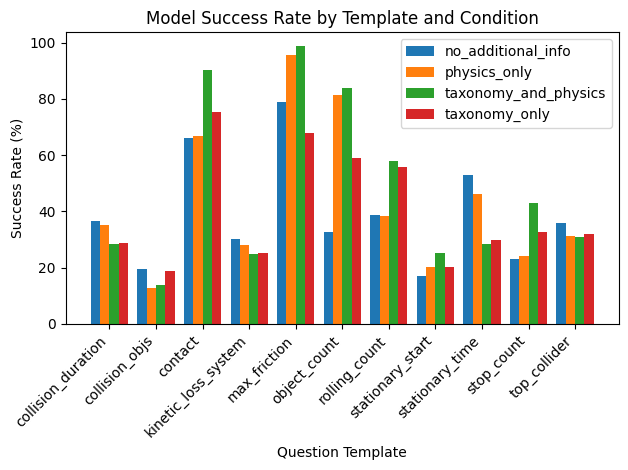

In [3]:
import re

# Build your DataFrame
df = pd.DataFrame(dfs)
# df = pd.DataFrame(enhanced_acc)

# 1) Tag each row with its template, including fallbacks
TEMPLATE_PATTERNS = [
    (
        "contact",
        r"^Are there any moments in the video where two or more objects collide or make physical contact\?$",
    ),
    ("object_count", r"^How many distinct physical objects appear during the video\?$"),
    (
        "stop_count",
        r"^How many objects come to a complete stop during the video that we can see\?$",
    ),
    (
        "rolling_count",
        r"^How many objects display rolling motion at any point in the video\?$",
    ),
    (
        "collision_objs",
        r"^How many unique objects were involved in collision throughout the video\?$",
    ),
    # ("top_collider", r"^Which object(?:\(s\))? were involved in the most collisions with other objects\?$"),
    (
        "top_collider",
        r"^Which object (?:was|were) involved in the most collisions with other objects\?$",
    ),
    # ("kinetic_loss_system",
    #                     r"^What percentage of the system(?:’|'s) kinetic energy was lost when the .+ collided with the .+\?$"),
    (
        "kinetic_loss_system",
        r"^What percentage of the system[’']s kinetic energy was lost when the .+ collided with the .+\?$",
    ),
    # ("kinetic_loss_system",
    #                     r"^What percentage of the system(?:’|'s) kinetic energy was lost when the .+ collided with the .+\?$"),
    (
        "kinetic_loss_obj",
        r"^How much kinetic energy did .+ lose during the collision\?$",
    ),
    # ("collision_duration", r"^How long did the collision between .+ and .+ last \(video fps is \d+\)\\?$"),
    (
        "collision_duration",
        r"^How long did the collision between .+ and .+ last \(video fps is \d+\)\?$",
    ),
    # How long did the collision between darkcyan sphere and hotpink sphere last (video fps is 25)?
    # ("collision_duration",
    #                     r"^How long did the collision between the .+ and the .+ last(?: \(video fps is \d+\))?\?$"),
    ("stationary_time", r"^How many seconds did the .+ spend stationary\?$"),
    (
        "stationary_start",
        r"^At what time in the video does the .+ first become stationary\?$",
    ),
    ("max_friction", r"^Which object had the highest friction coefficient\?$"),
    # FALLBACKS
    ("yesno", r"^(?:Are|Is|Do|Does|Has|Have|Can|Could|Will|Would).*\?$"),
    ("count", r"^How many .+\?$"),
    ("property", r"^What (?:is|are) the .+\?$"),
]
# Which object(s) were involved in the most collisions with other objects?


def assign_template(q):
    for name, pat in TEMPLATE_PATTERNS:
        if re.match(pat, q):
            return name
    print("q", q)
    return "unknown"


df["template"] = df["question"].apply(assign_template)

# 2) (Optionally) inspect how many fell into 'unknown'
n_unknown = (df["template"] == "unknown").sum()
if n_unknown > 0:
    print(
        f"⚠️  {n_unknown} questions didn’t match any pattern and are labeled 'unknown'."
    )

# 3) Drop unknowns before plotting
df = df[df["template"] != "unknown"]

# 4) Summarize and pivot
summary = (
    df.groupby(["template", "option"])
    .agg(n_total=("correct", "count"), n_correct=("correct", "sum"))
    .reset_index()
)
summary["success_pct"] = summary["n_correct"] / summary["n_total"] * 100
pivot = summary.pivot(index="template", columns="option", values="success_pct").fillna(
    0
)

# 5) If pivot is empty, bail out
if pivot.empty:
    print("❗ No templates remained after filtering — check your patterns.")
else:
    # 6) Plot
    labels = pivot.index.tolist()
    x = np.arange(len(labels))
    width = 0.2

    fig, ax = plt.subplots()
    for i, opt in enumerate(pivot.columns):
        ax.bar(x + i * width, pivot[opt], width, label=opt)

    ax.set_xticks(x + width * (len(pivot.columns) - 1) / 2)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Question Template")
    ax.set_ylabel("Success Rate (%)")
    ax.set_title("Model Success Rate by Template and Condition")
    ax.legend()

    plt.tight_layout()
    plt.show()